# Environment Setup and Data Preparation

In [1]:
import spacy

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gender_guesser.detector as gender

from scipy.stats import zscore, shapiro, levene, ttest_ind, mannwhitneyu

# Loading and Formatting the Dataset
## Creating the datetime format column:

In [2]:
df = pd.read_csv('anonymized_output.csv')
df['dates'] = pd.to_datetime(df['dates'])

# Dataset Inspection
## Reviewer names in the original dataset are anonymized to protect their privacy.
Also the original dataset does NOT include any gender information. The 4th column you see here is inferred utilizing gender_guesser library.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   names            451 non-null    object        
 1   dates            451 non-null    datetime64[ns]
 2   comments         451 non-null    object        
 3   inferred_gender  451 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 14.2+ KB


## Hourly distribution:

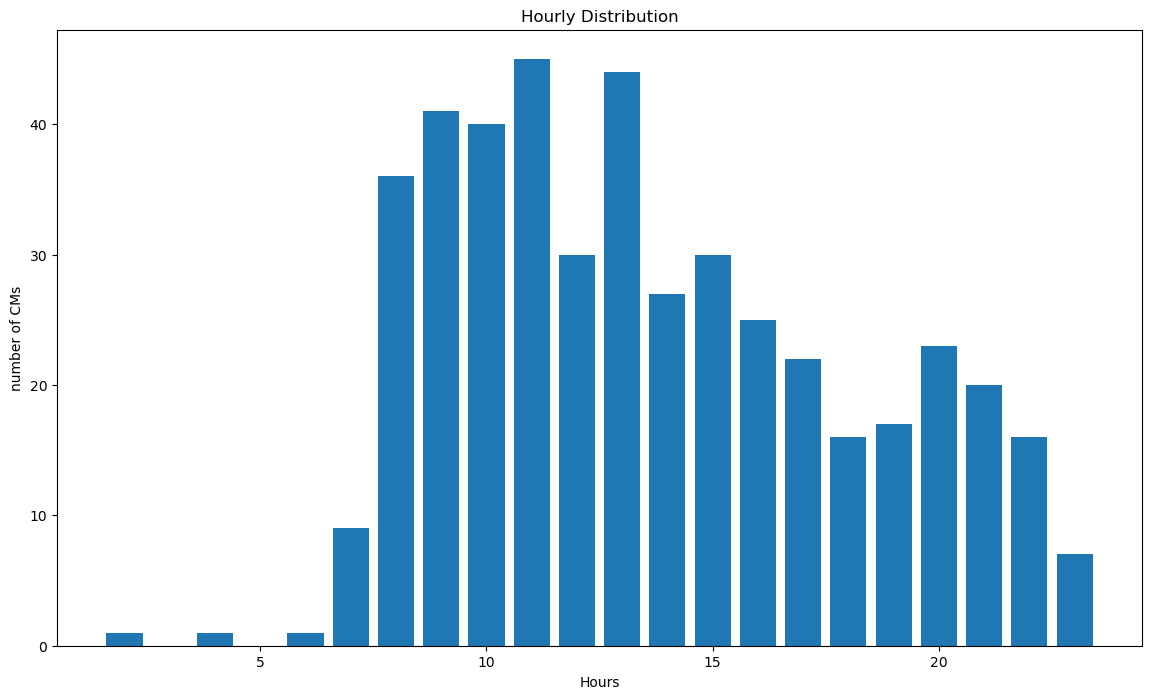

In [4]:
hours_groups = df.groupby(df['dates'].dt.hour).size()

plt.figure(figsize=(14,8))
plt.bar(hours_groups.index, hours_groups.values)
plt.title('Hourly Distribution')
plt.xlabel('Hours')
plt.ylabel('number of CMs');

# Attribute Engineering
## Gender Inference from Reviewer Names
### PLEASE NOTE: In the original private dataset, reviewer first names were processed using `gender.detector` to derive an `inferred_gender` column. For privacy reasons, names were removed from the published dataset and replaced with anonymized reviewer IDs.

In [5]:
# If is used to avoid recreating the column
if 'inferred_gender' not in df.columns:
    gen_detector = gender.Detector(case_sensitive=False)
    
    df['gender'] = df['names'].apply(lambda x: gen_detector.get_gender(str(x).lower().split(' ')[0]))
    df['gender'] = df['gender'].replace({
        'mostly_male': 'male',
        'mostly_female': 'female',
        'andy': 'unknown',
    })

## Gender Distribution:

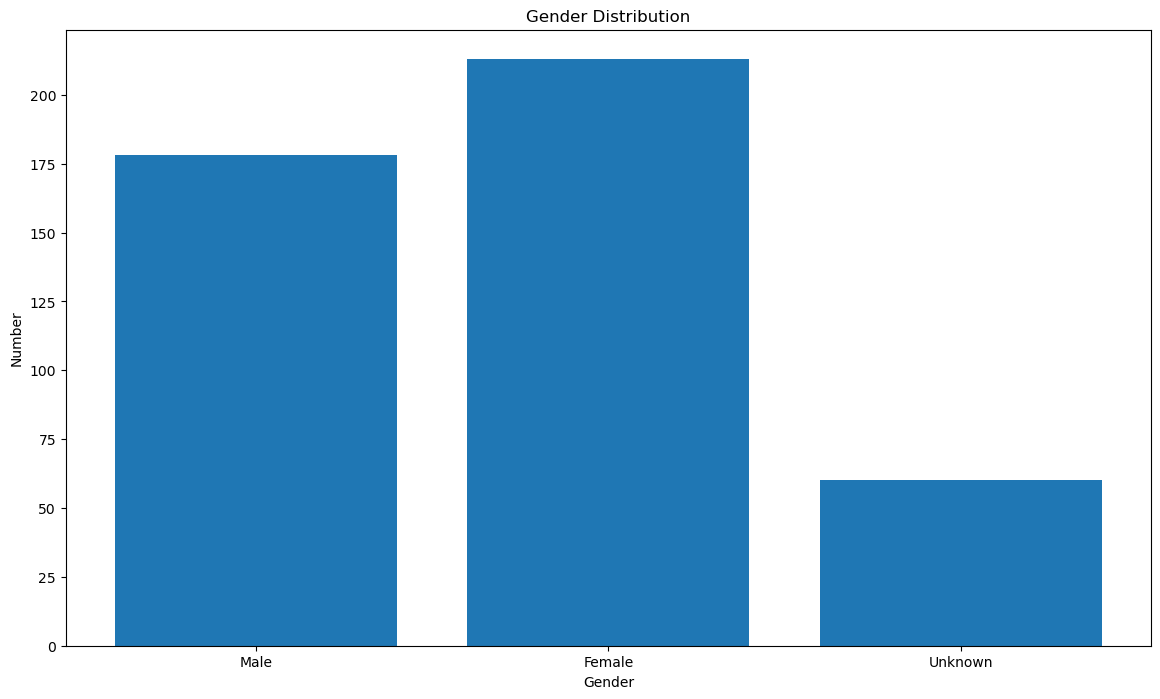

In [6]:
plt.figure(figsize=(14,8))
plt.bar(['Male', 'Female', 'Unknown'], [(df['inferred_gender'] == 'male').sum(), (df['inferred_gender'] == 'female').sum(), (df['inferred_gender'] == 'unknown').sum()])
plt.ylabel('Number')
plt.xlabel('Gender')
plt.title('Gender Distribution');

# Natural Language Processing (NLP)

## Installing and Loading the spaCy Language Model
### Lightweight version (sm) has been used:

In [7]:
# !python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

## Part-of-Speech Frequency Extraction

In [8]:
noun_count = {}
verb_count = {}
adj_count = {}

for cm in df['comments']:
    doc = nlp(cm)
    for token in doc:
        if token.pos_ == 'NOUN':
            if str(token).lower() in noun_count.keys():
                noun_count[str(token).lower()] += 1
            else:
                noun_count[str(token).lower()] = 1
        elif token.pos_ == 'VERB':
            if str(token).lower() in verb_count.keys():
                verb_count[str(token).lower()] += 1
            else:
                verb_count[str(token).lower()] = 1
        elif token.pos_ == 'ADJ':
            if str(token).lower() in adj_count.keys():
                adj_count[str(token).lower()] += 1
            else:
                adj_count[str(token).lower()] = 1

noun_count = dict(sorted(noun_count.items(), key = lambda x: x[1], reverse = True))
verb_count = dict(sorted(verb_count.items(), key = lambda x: x[1], reverse = True))
adj_count = dict(sorted(adj_count.items(), key = lambda x: x[1], reverse = True))
print(f'Nouns and their counts: {noun_count}')
print('')
print(f'Verbs and their counts: {verb_count}')
print('')
print(f'Adjectives and their counts: {adj_count}')

Nouns and their counts: {'cheese': 118, 'butter': 80, 'jam': 57, 'cream': 56, 'chocolate': 51, 'layer': 46, 'top': 44, 'strawberries': 41, 'slice': 36, 'croissants': 35, 'croissant': 31, 'egg': 31, 'topping': 26, 'sprinkles': 26, 'honey': 25, 'strawberry': 23, 'sugar': 21, 'combination': 21, 'slices': 20, 'bit': 20, 'salmon': 20, 'oven': 18, 'crispy': 16, 'brie': 16, 'chicken': 15, 'salt': 14, 'touch': 13, 'pastry': 13, 'pieces': 13, 'peanut': 13, 'lemon': 12, 'bite': 12, 'rocket': 10, 'sauce': 10, 'pepper': 10, 'flakes': 10, 'taste': 10, 'spread': 10, 'tomato': 10, 'ham': 9, 'course': 9, 'breakfast': 9, 'raspberries': 9, 'avocado': 9, 'paste': 8, 'pine': 8, 'nuts': 8, 'walnuts': 8, 'lettuce': 8, 'coffee': 8, 'ah': 7, 'way': 7, 'pesto': 7, 'luxury': 7, 'banana': 7, 'pistachio': 7, 'bacon': 7, 'herb': 7, 'mascarpone': 7, 'chives': 7, 'onion': 7, 'morning': 7, 'dollop': 7, 'lavender': 6, 'spring': 6, 'home': 6, 'sausage': 6, 'raspberry': 6, 'syrup': 6, 'eggs': 6, 'toppings': 6, 'party': 

##  Defining Categories and Time Filtering
### Grouping Culinary Nouns into Topping Categories:

In [9]:
df_meal = df.copy()

# There are 3 comments between 12 am and 7 am which we don't count them on our analysis
df_meal = df_meal[df_meal['dates'].dt.hour > 7]
group1 = ['almond', 'chia', 'hazelnut', 'hazelnuts', 'nut', 'nuts', 'peanut', 'peanuts', 'pecans', 'pine', 'pistachio', 'pistachios', 'seed', 'seeds', 'sesame', 'walnuts',]
# group2 = ['jam', 'apple', 'apricots', 'banana', 'blackberries', 'blueberries', 'cherries', 'cherry', 'compote', 'dates', 'fig', 'figs', 'fruit', 'grapes', 'guava', 'lemon', 'lime', 'passionfruit', 'pear', 'pineapple', 'raspberries', 'raspberry', 'strawberries', 'strawberry', 'tomato', 'tomatoes']
# group2 = ['coffee', 'tea', 'americano', 'matcha', 'tea', 'milk', 'juice']
group2 = ['egg', 'eggs', 'chicken', 'bacon',  'prosciutto', 'beef', 'carpaccio', 'salami',  'duck',  'entrecôte', 'burger', 'shawarma', 'guanciale', ]
df_meal['group1'] = df_meal['comments'].apply(lambda x: 1 if any(item in str(x).lower() for item in group1) else 0)
df_meal['group2'] = df_meal['comments'].apply(lambda x: 1 if any(item in str(x).lower() for item in group2) else 0)
# Uncomment in case of comparison group percentages with each other
# df_meal['group1'] /= df_meal['group1'].sum()
# df_meal['group2'] /= df_meal['group2'].sum()

# Use .mean() in case of showing the percentage of all comments published on the hour
group1_hourly = df_meal.groupby(df_meal['dates'].dt.hour)['group1'].mean()
group2_hourly = df_meal.groupby(df_meal['dates'].dt.hour)['group2'].mean()

## Hourly Category Trend Analysis
### Calculated the hourly proportion of reviews mentioning each food category, visualized their time-of-day patterns, and assessed their linear relationship with hour of publication

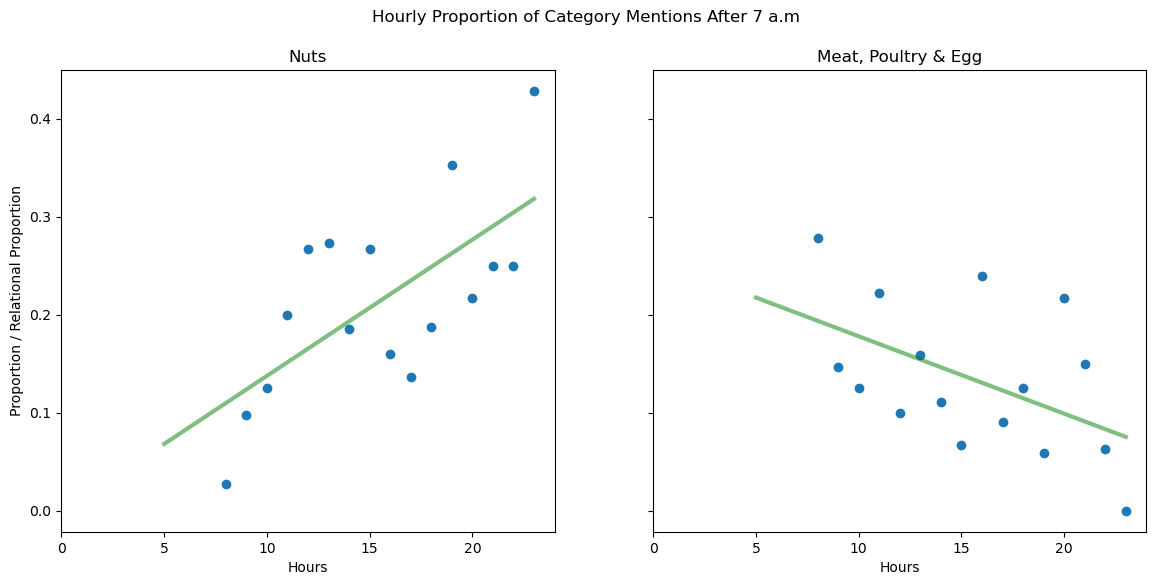

The correlation of first group hourly proportion with hour of day is 0.676.
The correlation of second group hourly proportion with hour of day is -0.501.


In [10]:
m1, b1 = np.polyfit(group1_hourly.index.to_numpy(), group1_hourly.values, 1)
x_line1 = [5,23]
y_line1 = [m1*5+b1, m1*23+b1]
m2, b2 = np.polyfit(group2_hourly.index.to_numpy(), group2_hourly.values, 1)
x_line2 = [5,23]
y_line2 = [m2*5+b2, m2*23+b2]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)
ax[0].scatter(group1_hourly.index, group1_hourly.values)
ax[0].plot(x_line1, y_line1, color='green', linewidth=3, alpha=0.5)
ax[1].scatter(group2_hourly.index, group2_hourly.values)
ax[1].plot(x_line2, y_line2, color='green', linewidth=3, alpha=0.5)
ax[0].set_title('Nuts')
ax[1].set_title('Meat, Poultry & Egg')
ax[0].set_xlabel('Hours')
ax[1].set_xlabel('Hours')
ax[0].set_ylabel('Proportion / Relational Proportion')
fig.suptitle('Hourly Proportion of Category Mentions After 7 a.m')
ax[0].set_xlim((0, 24))
ax[1].set_xlim((0, 24))
plt.show()
print(f'The correlation of first group hourly proportion with hour of day is {np.corrcoef(group1_hourly.index, group1_hourly.values)[0,1].round(3)}.')
print(f'The correlation of second group hourly proportion with hour of day is {np.corrcoef(group2_hourly.index, group2_hourly.values)[0,1].round(3)}.')

### Interpretation: The hourly proportion of nut-related mentions showed a clear positive association with time of day, indicating that these toppings were mentioned more frequently in later hours, whereas meat, poultry, and egg-related mentions showed a moderate negative association, suggesting that these categories became less frequent as the day progressed.

## Co-Occurrence Analysis of Groups

In [11]:
lift = (df_meal[(df_meal['group1'] == 1) & (df_meal['group2'] == 1)].size * (df_meal.size)) / ((df_meal[(df_meal['group1'] == 1)].size) * (df_meal[(df_meal['group2'] == 1)].size))
print(f'The lift between the two groups is {round(lift,3)}.')
print('People in the groups are MORE likely than expected to prefer both toppings together.' if lift > 1 else 'People in these groups are LESS likely than expected to prefer both toppings together.')

The lift between the two groups is 0.704.
People in these groups are LESS likely than expected to prefer both toppings together.


# Taste Groups Trends By Genders
## Generating Taste columns

In [12]:
sweet = ['apple', 'apricots', 'banana', 'blackberries', 'blueberries', 'cake', 'caramel', 'cherries', 'cherry', 'chocolate', 'compote', 'custard', 'dates', 'fig', 'figs', 'fluff', 'grapes', 'guava', 'honey', 'jam', 'marshmallow', 'nutella', 'paashagel', 'passionfruit', 'pear', 'pineapple', 'praline', 'pudding', 'raspberries', 'raspberry', 'sprinkles', 'strawberries', 'strawberry', 'sugar', 'syrup', 'vanilla', 'waffle']
savory = ['arugula', 'avocado', 'bacon', 'basil', 'beef', 'brie', 'butter', 'camembert', 'capers', 'carpaccio', 'cheese', 'chicken', 'chili', 'chives', 'cod', 'coriander', 'cottage', 'cream', 'creme', 'cucumber', 'dill', 'dressing', 'duck', 'egg', 'eggs', 'feta', 'fillet', 'fresch', 'garlic', 'guacamole', 'ham', 'hummus', 'iceberg', 'lemon', 'lime', 'liver', 'maio', 'majo', 'mascarpone', 'mayo', 'mayonnaise', 'mozzarella', 'mustard', 'oil', 'olives', 'onion', 'paprika', 'parma', 'peanut', 'pesto', 'prosciutto', 'rocket', 'salad', 'salami', 'salmon', 'sardines', 'sausage', 'soy', 'spinach', 'spread', 'teriyaki', 'thyme', 'tomato', 'tomatoes', 'tuna', 'vegetable', 'vinegar']
df_meal['sweet'] = df_meal['comments'].apply(lambda x: 1 if any( item in str(x).lower() for item in sweet) else 0)
df_meal['savory'] = df_meal['comments'].apply(lambda x: 1 if any(item in str(x).lower() for item in savory) else 0)

## Visualizing Gender-Based Taste Distribution

                    sweet    savory      both
inferred_gender                              
female           0.524444  0.476038  0.503067
male             0.333333  0.392971  0.343558
unknown          0.142222  0.130990  0.153374

52.44% of people who mentioned sweet, are female, 33.33% are male.
47.6% of people who mentioned savory, are female, 39.3% are male.



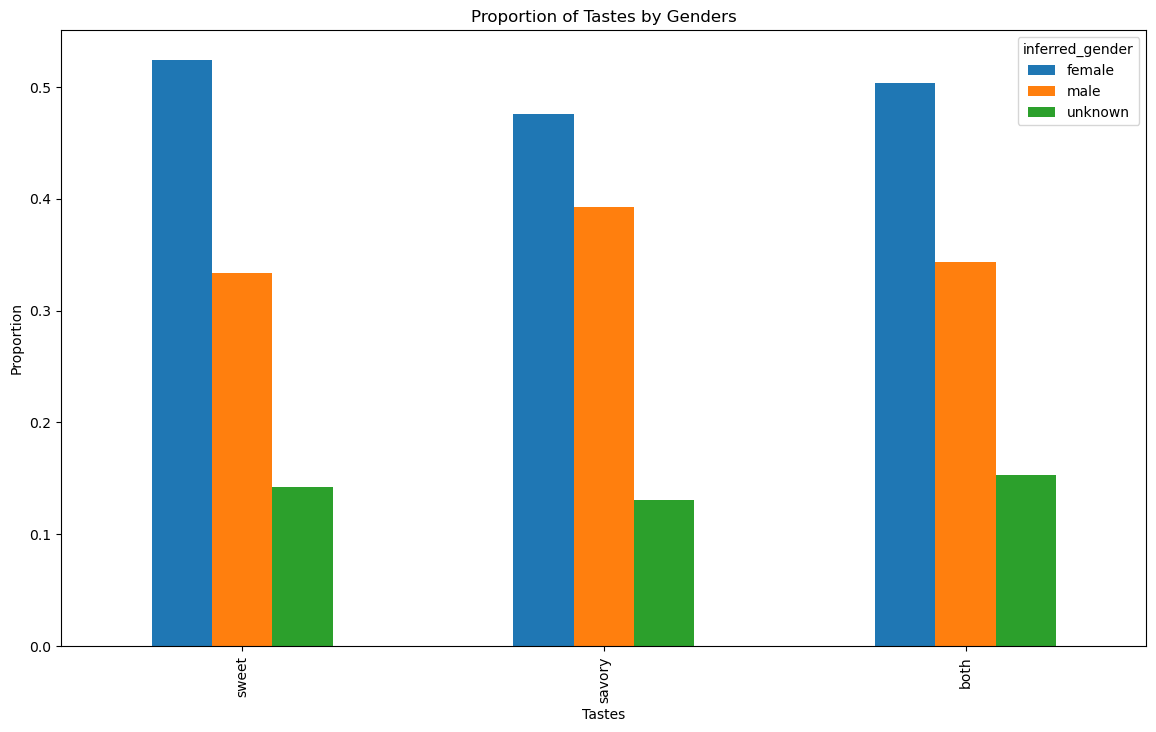

In [13]:
# This says, 52% of people who mentioned sweet, are female, 33% male and 14% unknown
df_by_gender = pd.DataFrame({'sweet': df_meal.groupby('inferred_gender')['sweet'].sum()/len(df_meal[df_meal['sweet'] == 1]),
                            'savory': df_meal.groupby('inferred_gender')['savory'].sum()/len(df_meal[df_meal['savory'] == 1]),
                            'both': ((df_meal['sweet'] == 1) & (df_meal['savory'] == 1)).groupby(df_meal['inferred_gender']).sum()/len(df_meal[(df_meal['sweet'] == 1) & (df_meal['savory'] == 1)]),
                            })
df_by_gender.T.plot(kind='bar', figsize = (14, 8))
plt.ylabel('Proportion')
plt.xlabel('Tastes')
plt.title('Proportion of Tastes by Genders')
print(df_by_gender)
print()
print(f'{round(df_by_gender.loc['female', 'sweet']*100, 2)}% of people who mentioned sweet, are female, {round(df_by_gender.loc['male', 'sweet']*100, 2)}% are male.')
print(f'{round(df_by_gender.loc['female', 'savory']*100, 2)}% of people who mentioned savory, are female, {round(df_by_gender.loc['male', 'savory']*100, 2)}% are male.\n')

## Visualizing Within-Gender Distribution of Tastes

                    sweet    savory      both
inferred_gender                              
female           0.567308  0.716346  0.394231
male             0.433526  0.710983  0.323699
unknown          0.551724  0.706897  0.431034

Among females 0.567% mentioned sweet things and 0.716% mentioned something savory.



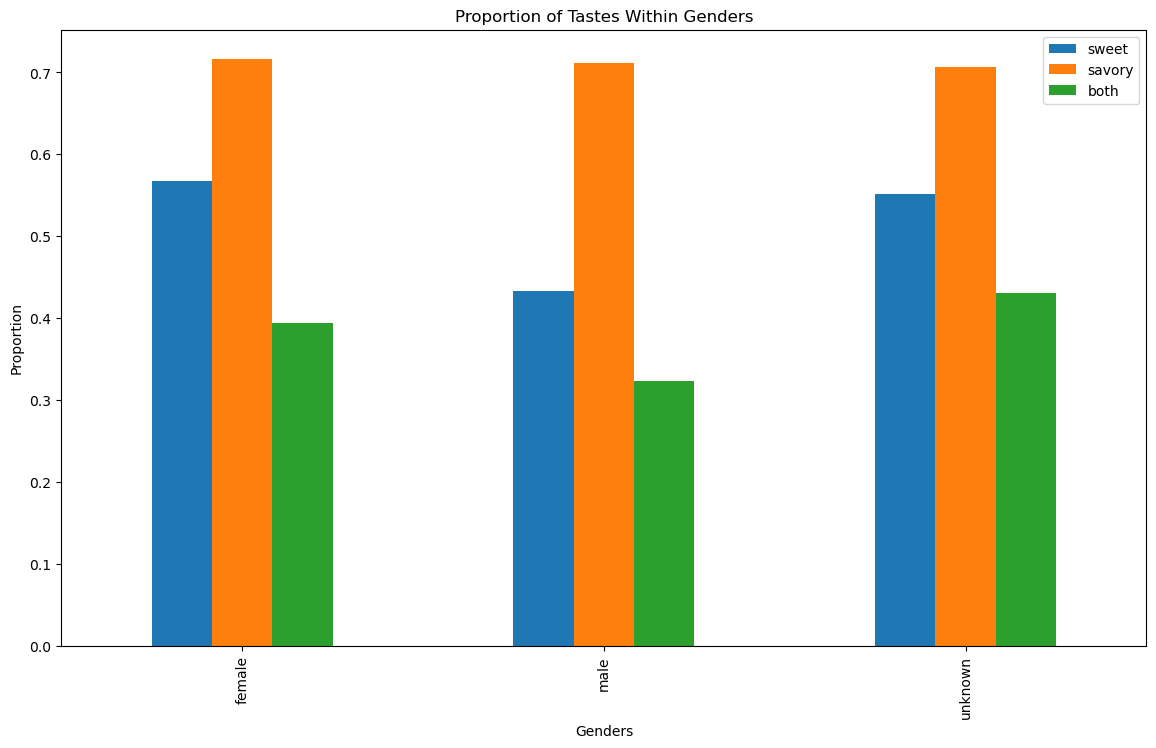

In [14]:
# Among females 56% have said something sweety, 71% have said something savory and 39% both
df_by_taste = pd.DataFrame({'sweet': df_meal.groupby('inferred_gender')['sweet'].mean(),
                            'savory': df_meal.groupby('inferred_gender')['savory'].mean(),
                            'both': ((df_meal['sweet'] == 1) & (df_meal['savory'] == 1)).groupby(df_meal['inferred_gender']).mean(),
                            })
df_by_taste.plot(kind='bar', figsize = (14, 8))
plt.ylabel('Proportion')
plt.xlabel('Genders')
plt.title('Proportion of Tastes Within Genders')
print(df_by_taste)
print()
print(f'Among females {round(df_by_taste.loc['female','sweet'],3)}% mentioned sweet things and {round(df_by_taste.loc['female','savory'],3)}% mentioned something savory.\n')

# Complexity Analysis
## Extracting Culinary Nouns, Verbs and Adjectives for further Analysis

In [15]:
culinary_nouns = ['cheese', 'butter', 'jam', 'cream', 'chocolate', 'strawberries', 'egg', 'sprinkles', 'honey', 'strawberry', 'sugar', 'salmon', 'brie', 'chicken', 'salt', 'pastry', 'peanut', 'lemon', 'rocket', 'sauce', 'pepper', 'spread', 'tomato', 'ham', 'raspberries', 'avocado', 'paste', 'nuts', 'walnuts', 'lettuce', 'pesto', 'banana', 'pistachio', 'bacon', 'mascarpone', 'chives', 'onion', 'lavender', 'sausage', 'raspberry', 'syrup', 'eggs', 'curd', 'mustard', 'sandwich', 'mayonnaise', 'fillet', 'cucumber', 'salad', 'prosciutto', 'fig', 'bread', 'pineapple', 'caramel', 'vanilla', 'mozzarella', 'dill', 'beef', 'pistachios', 'arugula', 'chili', 'mayo', 'filling', 'cake', 'hazelnut', 'roll', 'custard', 'basil', 'fruit', 'tomatoes', 'chips', 'crossaint', 'apple', 'waffle', 'paashagel', 'bun', 'marshmallow', 'compote', 'pecans', 'parmesan', 'cucumbers', 'blueberries', 'grapes', 'onions', 'cheesecake', 'buttercream', 'toast', 'milk', 'frikandel', 'garlic', 'cherry', 'figs', 'mint', 'seed', 'croquette', 'carpaccio', 'dressing', 'salami', 'sesame', 'apricots', 'lime', 'coriander', 'iceberg', 'cherries', 'baklava', 'feta', 'hummus', 'breast', 'blackberries', 'sardines', 'oil', 'beurre', 'soy', 'teriyaki', 'spices', 'quark', 'pumpkin', 'soup', 'almond', 'maple', 'filet', 'dip', 'spice', 'pasta', 'rusk', 'rusks', 'guacamole', 'guava', 'chutney', 'moccassant', 'cinnamon', 'nutella', 'tompouce', 'passionfruit', 'fudge', 'tiramisu', 'ladyfingers', 'cocoa', 'frinkandelcroissant', 'pudding', 'peanuts', 'baguette', 'crackling', 'chia', 'shumai', 'dumplings', 'paprika', 'tuna', 'duck', 'liver', 'grain', 'fenugreek', 'capers', 'vinegar', 'dates', 'truffle', 'maio', 'olives', 'cod', 'praline', 'crompouce', 'bavette', 'seeds', 'americain', 'hazelnuts', 'poutine', 'lotus', 'speculaas', 'cookies', 'chipotle', 'creme', 'tortilla', 'cumin', 'majo', 'thyme', 'parma', 'matcha', 'entrecôte', 'cheeses', 'burger', 'vegetable', 'pear', 'anise', 'frangipane', 'dairy', 'shawarma', 'marshmallows', 'nut', 'potato', 'dough', 'soufflé', 'spinach', 'yolk', 'ragout', 'food', 'wafer', 'carbonara', 'guanciale', 'sausages', 'speculoos', 'camembert', 'prawns', 'crab']
culinary_verbs = ['top', 'spread', 'topped', 'cut', 'smoked', 'add', 'baked', 'salted', 'whipped', 'filled', 'melted', 'dip', 'boiled', 'fill', 'melt', 'prepare', 'grilled', 'scrambled', 'fried', 'mix', 'bake', 'sprinkle', 'crumbled', 'heat', 'added', 'caramelized', 'marinated', 'spreading', 'pickled', 'dipped', 'roll', 'warmed', 'smash', 'baking', 'pipe', 'spray', 'cutting', 'cream', 'chopped', 'warm', 'combine', 'poured', 'broiled', 'drain', 'mash', 'prepared', 'seasoned', 'beat', 'fills', 'pour', 'caramelised', 'smashed', 'squeezed', 'dried']
culinary_adjs = ['delicious', 'fresh', 'warm', 'little', 'nice', 'sweet', 'tastiest', 'tasty', 'soft', 'white', 'ultimate', 'creamy', 'french', 'good', 'homemade', 'fried', 'young', 'perfect', 'yummy', 'thin', 'extra', 'great', 'salty', 'healthy', 'pure', 'thick', 'old', 'special', 'big', 'mature', 'lukewarm', 'roasted', 'lovely', 'small', 'spicy', 'better', 'generous', 'new', 'baked', 'more', 'powdered', 'red', 'sour', 'crunchy', 'dutch', 'festive', 'mini', 'golden', 'spreadable', 'grated', 'coarse', 'plain', 'light', 'sliced', 'frozen', 'luxurious', 'brown', 'green', 'unhealthy', 'italian', 'raw', 'hot', 'black', 'cut', 'poached', 'full', 'scrambled', 'natural', 'fancy', 'finishing', 'nicer', 'greasy', 'fat', 'shaped', 'floral', 'whole', 'surprising', 'balanced', 'scented', 'blue', 'brazilian', 'colorful', 'crushed', 'heavenly', 'swiss', 'chinese', 'bad', 'fantastic', 'huge', 'juicy', 'tough', 'german', 'exotic', 'purple', 'smoked', 'surinamese', 'legendary', 'healthiest', 'culinary', 'artisanal', 'sticky', 'mashed', 'double', 'marinated', 'savory', 'british', 'toasted', 'yellow', 'spanish', 'fluffy', 'dark', 'pink', 'nutty', 'rich', 'colored', 'aged', 'organic', 'english']

## Defining Complexity Features 
### Checking the Correlations Among the Features:

In [16]:
df_meal['word_counts'] = df_meal['comments'].apply(lambda x: len(x.split()))

df_meal['noun_counts'] = df_meal['comments'].apply(lambda x: sum(1 for item in culinary_nouns if item in x))
df_meal['verb_counts'] = df_meal['comments'].apply(lambda x: sum(1 for item in culinary_verbs if item in x))
df_meal['adj_counts'] = df_meal['comments'].apply(lambda x: sum(1 for item in culinary_adjs if item in x))

print("Correlations between Complexity Features:")
df_meal[['word_counts','noun_counts', 'verb_counts', 'adj_counts']].corr()

Correlations between Complexity Features:


,word_counts,noun_counts,verb_counts,adj_counts
word_counts,1.000000,0.489159,0.570937,0.702487
noun_counts,0.489159,1.000000,0.518569,0.364306
verb_counts,0.570937,0.518569,1.000000,0.461621
adj_counts,0.702487,0.364306,0.461621,1.000000


## Visualizing Complexity Features
### Their Distribution by Genders:

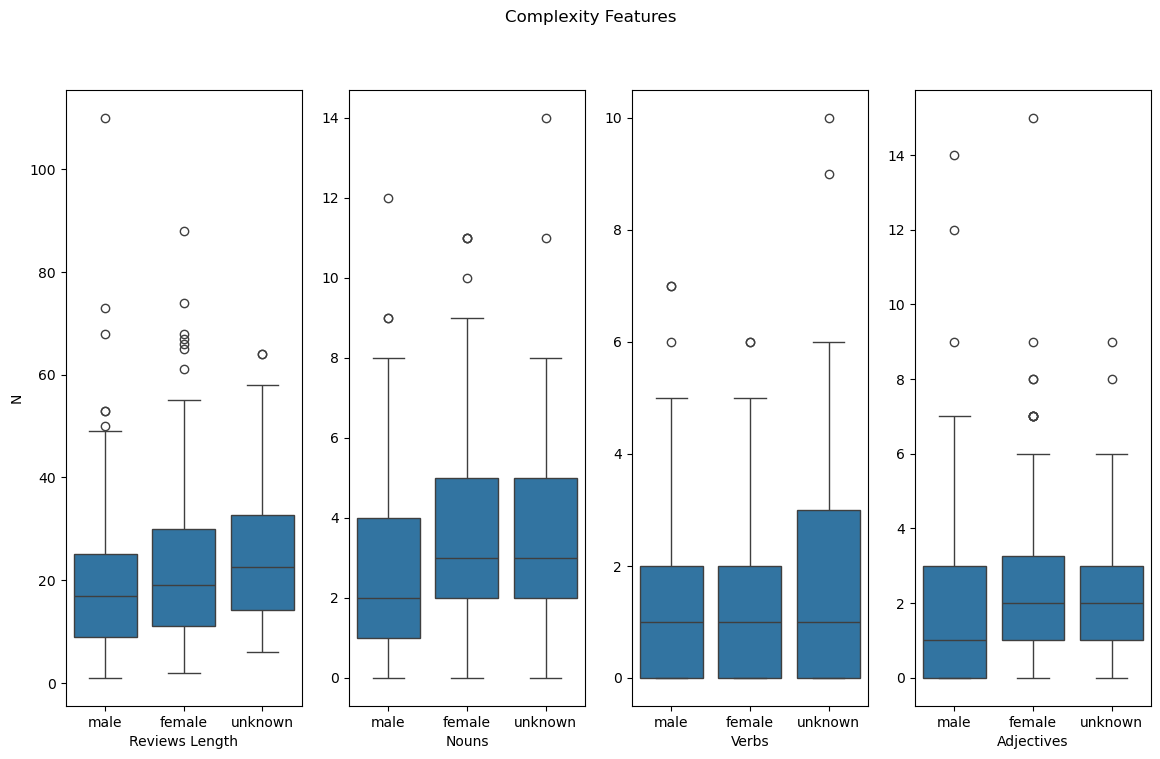

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(14, 8))

sns.boxplot(data=df_meal, x='inferred_gender', y = 'word_counts', ax=ax[0])
sns.boxplot(data=df_meal, x='inferred_gender', y = 'noun_counts', ax=ax[1])
sns.boxplot(data=df_meal, x='inferred_gender', y = 'verb_counts', ax=ax[2])
sns.boxplot(data=df_meal, x='inferred_gender', y = 'adj_counts', ax=ax[3])
ax[0].set_ylabel('N')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')
ax[0].set_xlabel('Reviews Length')
ax[1].set_xlabel('Nouns')
ax[2].set_xlabel('Verbs')
ax[3].set_xlabel('Adjectives')
fig.suptitle('Complexity Features')
plt.show()

### Their Means by Gender:

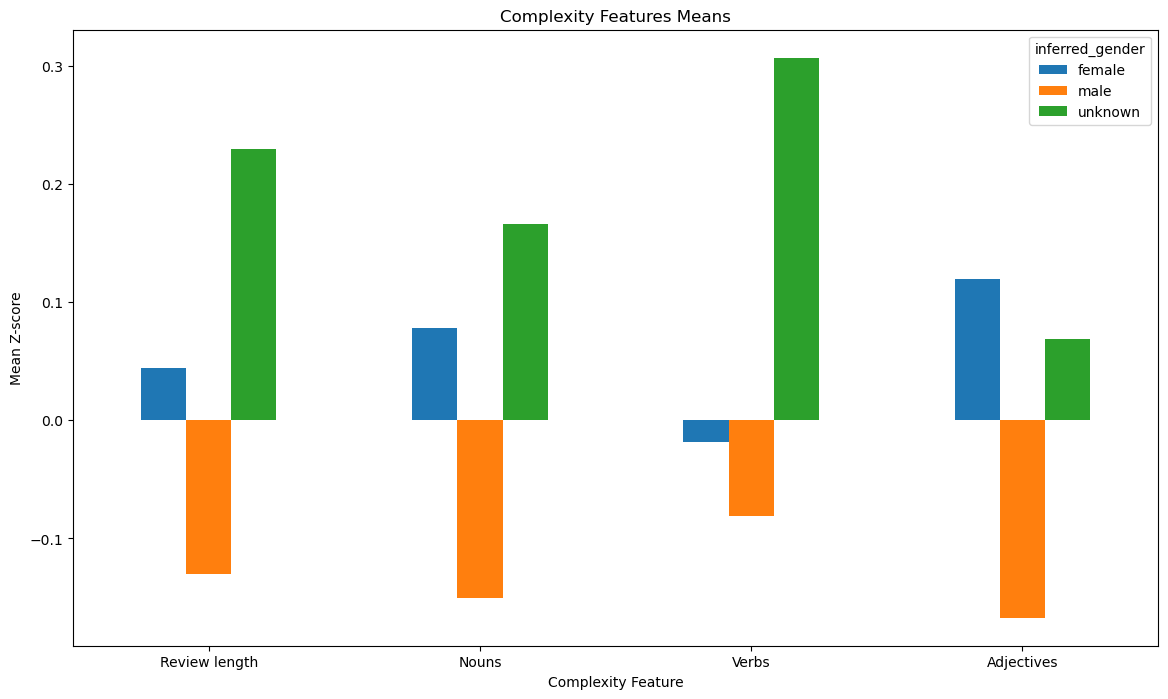

In [18]:
cols = ['word_counts', 'noun_counts', 'verb_counts', 'adj_counts']

df_meal_z = df_meal.copy()
df_meal_z[cols] = zscore(df_meal[cols])

ax = df_meal_z.groupby('inferred_gender')[cols].mean().T.plot(kind='bar', figsize=(14, 8))
ax.set_ylabel('Mean Z-score')
ax.set_xlabel('Complexity Feature')
ax.set_xticklabels(['Review length', 'Nouns', 'Verbs', 'Adjectives'], rotation = 0)
ax.set_title('Complexity Features Means')
plt.show()

## Assigning complexity Coeffitients
### Visualizing Complexity by Gender

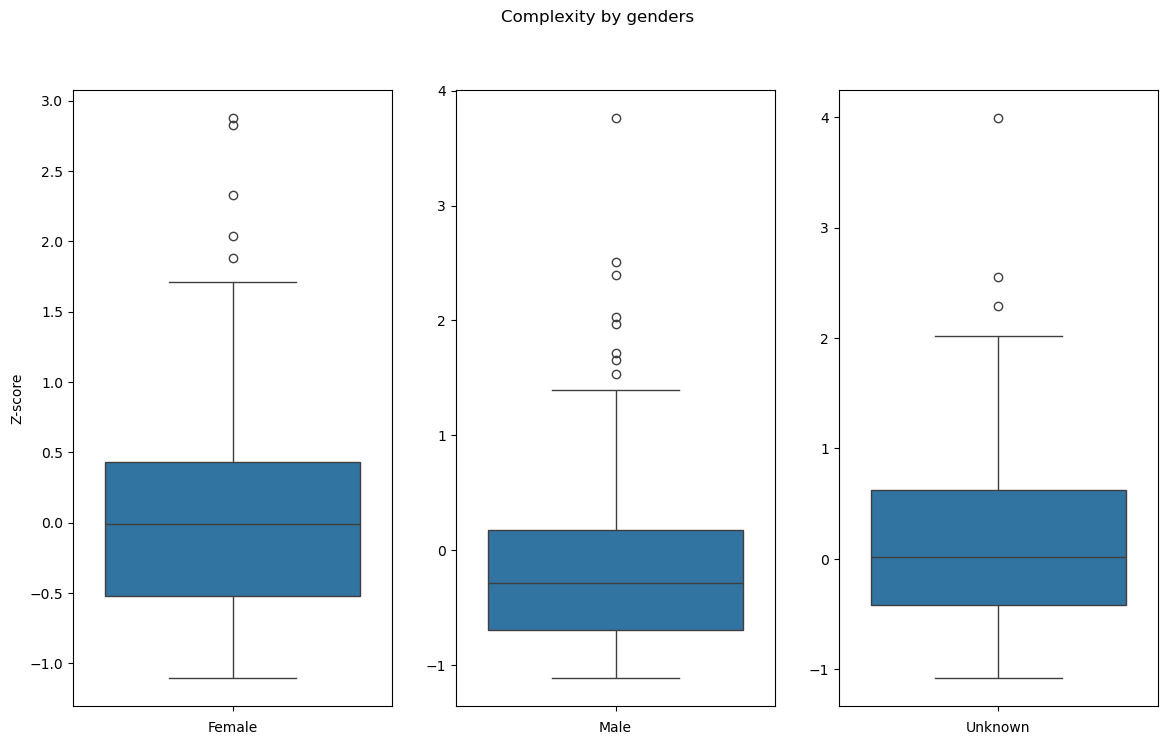

In [19]:
df_meal['complexity'] = (zscore(df_meal['word_counts'])*0.1) + (zscore(df_meal['noun_counts'])*0.3) + (zscore(df_meal['verb_counts'])*0.3) + (zscore(df_meal['adj_counts'])*0.3)

fig, ax = plt.subplots(1, 3, figsize=(14, 8))

sns.boxplot(data=df_meal.loc[df_meal['inferred_gender'] == 'female'], y = 'complexity', ax=ax[0])
sns.boxplot(data=df_meal.loc[df_meal['inferred_gender'] == 'male'], y = 'complexity', ax=ax[1])
sns.boxplot(data=df_meal.loc[df_meal['inferred_gender'] == 'unknown'], y = 'complexity', ax=ax[2])

ax[0].set_xlabel('Female')
ax[1].set_xlabel('Male')
ax[2].set_xlabel('Unknown')
ax[0].set_ylabel('Z-score')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
fig.suptitle('Complexity by genders')
plt.show()

## Hypothesis
### H0 = "The mean complexity of female reviews equals to the mean complexity of male reviews."

In [20]:
tmp = df_meal[df_meal['inferred_gender'].isin(['male', 'female'])][['inferred_gender', 'complexity']].dropna()
female = tmp.loc[tmp['inferred_gender'] == 'female', 'complexity']
male   = tmp.loc[tmp['inferred_gender'] == 'male', 'complexity']

print('female n, mean, median, std:', len(female), female.mean(), female.median(), female.std())
print('male   n, mean, median, std:', len(male), male.mean(), male.median(), male.std())

sh_f = shapiro(female)
sh_m = shapiro(male)
print('\nShapiro female:', sh_f)
print('Shapiro male  :', sh_m)

lev = levene(female, male)
print('\nLevene:', lev)

tres = ttest_ind(female, male, equal_var=False)
print('\nWelch t-test:', tres)

mwu = mannwhitneyu(female, male, alternative='two-sided')
print('Mann-Whitney U:', mwu)

# print('Because the Shapiro p-values were very small in both groups, the complexity scores were treated as non-normally distributed.\n Levene’s test was not significant, so there was no evidence of unequal variances between the male and female groups.\n Both the Welch t-test and the Mann-Whitney U test were significant, so the null hypothesis was rejected. Female reviews had significantly higher complexity scores than male reviews.\n Because the distributions were non-normal, the Mann-Whitney U result should be treated as the primary result, with the Welch t-test reported as supporting evidence. \n \n This difference was in the direction of higher female mean and median complexity scores.')

female n, mean, median, std: 208 0.05836401183917901 -0.006572476986152926 0.7388451821016006
male   n, mean, median, std: 173 -0.13238662911316915 -0.28553819704708194 0.7819232943391538

Shapiro female: ShapiroResult(statistic=np.float64(0.9396373238365577), pvalue=np.float64(1.3330619286533023e-07))
Shapiro male  : ShapiroResult(statistic=np.float64(0.883730043012908), pvalue=np.float64(2.3399303963400947e-10))

Levene: LeveneResult(statistic=np.float64(0.0018717736396017953), pvalue=np.float64(0.9655138726603032))

Welch t-test: TtestResult(statistic=np.float64(2.4306626356574896), pvalue=np.float64(0.015561476209865215), df=np.float64(358.1823256976426))
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(21304.5), pvalue=np.float64(0.0019711743817764065))


### &nbsp;&nbsp;&nbsp;&nbsp;Because the Shapiro p-values were very small in both groups, the complexity scores were treated as non-normally distributed.<br>&nbsp;&nbsp;&nbsp;&nbsp;Levene’s test was not significant, so there was no evidence of unequal variances between the male and female groups.<br>&nbsp;&nbsp;&nbsp;&nbsp;Both the Welch t-test and the Mann-Whitney U test were significant, so <b>the null hypothesis was rejected.</b><br>&nbsp;&nbsp;&nbsp;&nbsp;Female reviews had significantly higher complexity scores than male reviews.<br>&nbsp;&nbsp;&nbsp;&nbsp;Because the distributions were non-normal, the Mann-Whitney U result should be treated as the primary result, with the Welch t-test reported as supporting evidence. <br><br>&nbsp;&nbsp;&nbsp;&nbsp;This difference was in the direction of <b>higher female</b> mean and median complexity scores.